In [4]:
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from category_encoders import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
import seaborn as sns


In [8]:
%load_ext sql
%sql sqlite:///./data/nepal.sqlite

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
def wrangle(path):
    conn = sqlite3.connect(path)

    query = """
        SELECT distinct(i.building_id) AS b_id,
               s.*,
               d.damage_grade
        FROM id_map AS i
        JOIN building_structure AS s ON i.building_id = s.building_id
        JOIN building_damage AS d ON i.building_id = d.building_id
        WHERE district_id == 3
    """

    df = pd.read_sql(query, conn, index_col="b_id")
    # converting target to int
    df["severe_damage"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["severe_damage"]>3).astype(int) 

    df.drop(columns="damage_grade", inplace=True)

    # dropping leakage data
    drop_col = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_col, inplace=True)

    # dropping multicollinearity
    df.drop(columns="count_floors_pre_eq", inplace=True)

    # dropping high cardinality
    df.drop(columns="building_id", inplace=True)

    
    return df

In [22]:
df = wrangle("./data/nepal.sqlite")
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
87473,15,382,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87479,12,328,7,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,"Stone, mud mortar",1
87482,23,427,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87491,12,427,14,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87496,32,360,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1


<Axes: >

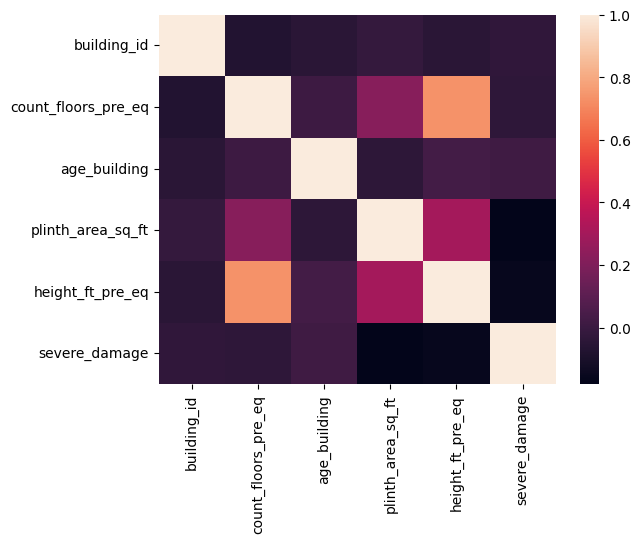

In [17]:
# df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True))

In [18]:
df["count_floors_pre_eq"].corr(df["severe_damage"])

-0.03517993526945271

In [19]:
df["height_ft_pre_eq"].corr(df["severe_damage"])

-0.15804371718380741

In [20]:
df.select_dtypes("int").nunique()

building_id            76533
count_floors_pre_eq        9
age_building             139
plinth_area_sq_ft       1198
height_ft_pre_eq          57
severe_damage              2
dtype: int64

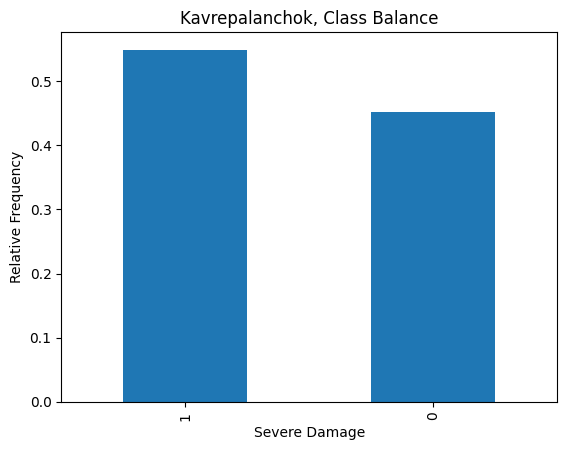

In [23]:
fig, ax = plt.subplots() 

df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar",
    ax=ax 
)
ax.set_xlabel("Severe Damage")
ax.set_ylabel("Relative Frequency")
ax.set_title("Kavrepalanchok, Class Balance");

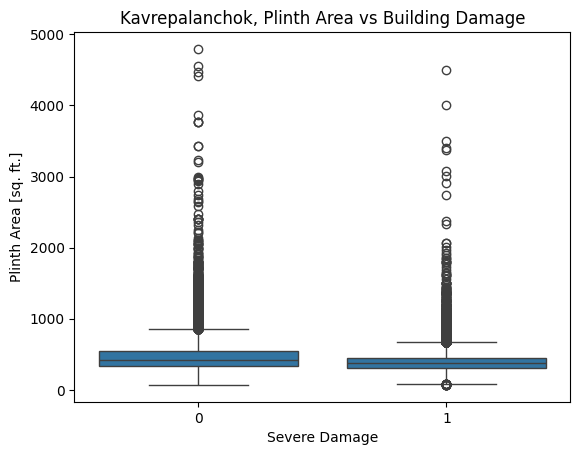

In [24]:
fig, ax = plt.subplots() 

sns.boxplot(x="severe_damage", y="plinth_area_sq_ft", data=df, ax=ax)

ax.set_xlabel("Severe Damage")
ax.set_ylabel("Plinth Area [sq. ft.]")
ax.set_title("Kavrepalanchok, Plinth Area vs Building Damage");

In [25]:
roof_pivot = pd.pivot_table(df, index="roof_type", values="severe_damage", aggfunc=np.mean).sort_values(by="severe_damage")
roof_pivot

/var/folders/xd/2zmv2h_n515gfxjmlgkg43tc0000gn/T/ipykernel_84029/688554147.py:1: FutureWarning: The provided callable <function mean at 0x10aca6660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  roof_pivot = pd.pivot_table(df, index="roof_type", values="severe_damage", aggfunc=np.mean).sort_values(by="severe_damage")


,severe_damage
roof_type,
RCC/RB/RBC,0.040715
Bamboo/Timber-Heavy roof,0.569477
Bamboo/Timber-Light roof,0.604842


In [26]:
X = df.drop(columns="severe_damage")
y = df["severe_damage"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (76533, 11)
y shape: (76533,)


In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (61226, 11)
y_train shape: (61226,)
X_val shape: (15307, 11)
y_val shape: (15307,)


In [28]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.55


In [29]:
model_lr = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
model_lr.fit(X_train, y_train)

/Users/ninadgawade/Documents/Projects/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('onehotencoder', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [30]:
lr_train_acc = accuracy_score(y_train, model_lr.predict(X_train))
lr_val_acc = model_lr.score(X_val, y_val)

print("Logistic Regression, Training Accuracy Score:", lr_train_acc)
print("Logistic Regression, Validation Accuracy Score:", lr_val_acc)

Logistic Regression, Training Accuracy Score: 0.6513246006598504
Logistic Regression, Validation Accuracy Score: 0.6522506042986869


In [31]:
depth_hyperparams = range(1, 16)
training_acc = []
validation_acc = []
for d in depth_hyperparams:
    model_dt = make_pipeline(
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth=d, random_state=42)
    )
    model_dt.fit(X_train, y_train)
    training_acc.append(model_dt.score(X_train, y_train))
    validation_acc.append(model_dt.score(X_val, y_val))

In [32]:
submission = pd.Series(validation_acc, index=depth_hyperparams)
submission

1     0.635004
2     0.635004
3     0.645391
4     0.652773
5     0.652904
6     0.658457
7     0.658457
8     0.662769
9     0.664533
10    0.665382
11    0.662899
12    0.660613
13    0.655321
14    0.655648
15    0.654733
dtype: float64

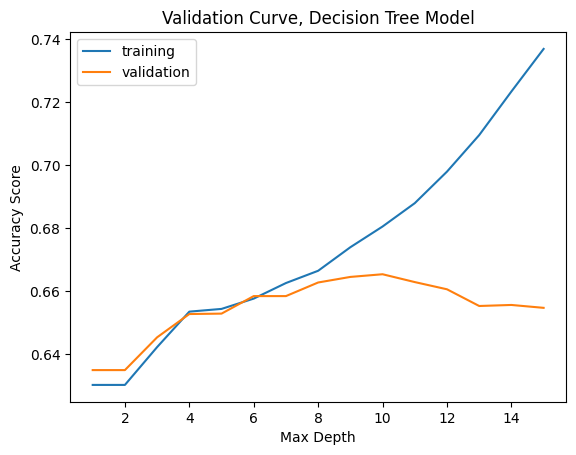

In [34]:
fig, ax = plt.subplots() 

ax.plot(depth_hyperparams, training_acc, label="training")

ax.plot(depth_hyperparams, validation_acc, label="validation") 

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy Score")
ax.set_title("Validation Curve, Decision Tree Model")

ax.legend();

In [35]:
final_model_dt = make_pipeline(
    OrdinalEncoder(),
    DecisionTreeClassifier(max_depth=10, random_state=42)
)
final_model_dt.fit(X_train, y_train)

,steps,"[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,mapping,"[{'col': 'land_surface_condition', 'data_type': dtype('O'), 'mapping': Flat ...2 dtype: int64}, {'col': 'foundation_type', 'data_type': dtype('O'), 'mapping': Mud mortar-St...2 dtype: int64}, ...]"
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [36]:
X_test = pd.read_csv("./data/kavrepalanchok-test-features.csv", index_col="b_id")
y_test_pred = final_model_dt.predict(X_test)
y_test_pred[:5]

array([1, 1, 1, 1, 0])

In [37]:
features = X_train.columns.to_list()
importances = final_model_dt.named_steps["decisiontreeclassifier"].feature_importances_
feat_imp = pd.Series((importances), index=features).sort_values()
feat_imp.head()

plan_configuration        0.004189
land_surface_condition    0.008599
foundation_type           0.009967
position                  0.011795
ground_floor_type         0.013521
dtype: float64

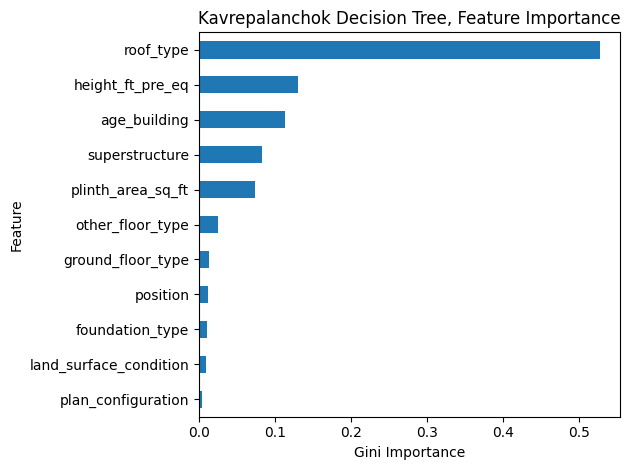

In [38]:
fig, ax = plt.subplots() 

feat_imp.plot(kind="barh", ax=ax)

ax.set_xlabel("Gini Importance")
ax.set_ylabel("Feature")
ax.set_title("Kavrepalanchok Decision Tree, Feature Importance")

fig.tight_layout()